In [13]:
%%writefile my_library.py

import requests
import pandas as pd
import json
import os
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import Image as DisplayImage, display
import io

# 1. THE DATA FETCHWER (requests)
def get_book_info(isbn):
    """Fetches real book metadata using an ISBN."""
    url = f"https://openlibrary.org/api/books?bibkeys=ISBN:{isbn}&format=json&jscmd=data"
    response = requests.get(url)
    return response.json()

# 2. THE CATALOG MANAGER (pandas)
def create_book_shelf(data_list):
    """Turns a list of book dictionaries into a searchable table."""
    return pd.DataFrame(data_list)

# 3. THE STORAGE SYSTEM (json & os)
def save_collection(collection, folder="my_archive"):
    """Saves your library to a JSON file in a specific directory."""
    if not os.path.exists(folder):
        os.makedirs(folder)

    path = os.path.join(folder, "library_data.json")
    with open(path, 'w') as f:
        json.dump(collection, f)
    return f"Library saved at: {path}"

# 4. THE VISUALIZER (matplotlib)
def plot_library_growth(years, book_counts):
    """Plots a graph showing how your library has grown."""
    plt.plot(years, book_counts, marker='o', color='brown')
    plt.title("Library Collection Growth")
    plt.xlabel("Year")
    plt.ylabel("Number of Books")
    plt.grid(True)
    plt.show()

# 5. THE COVER PROCESSOR (PIL)
def process_cover_image(image_path):
    """Opens a book cover and returns its dimensions."""
    with Image.open(image_path) as img:
        return f"Cover Size: {img.size} | Format: {img.format}"

# New function to download and display book cover
def download_and_display_cover(isbn):
    """Fetches book cover image from Open Library and displays it."""
    book_data = get_book_info(isbn)
    if book_data and f'ISBN:{isbn}' in book_data:
        details = book_data[f'ISBN:{isbn}']
        if 'cover' in details and 'large' in details['cover']:
            cover_url = details['cover']['large']
            print(f"Downloading cover from: {cover_url}")
            response = requests.get(cover_url)
            if response.status_code == 200:
                return DisplayImage(data=response.content)
            else:
                print(f"Failed to download cover: {response.status_code}")
        else:
            print(f"No cover image found for ISBN: {isbn}")
    else:
        print(f"No book data found for ISBN: {isbn}")
    return None

# New function to build a big library from a list of ISBNs
def build_big_library(isbn_list):
    """Fetches info for multiple ISBNs and creates a DataFrame."""
    all_books_data = []
    for isbn in isbn_list:
        book_info = get_book_info(isbn)
        if book_info and f'ISBN:{isbn}' in book_info:
            details = book_info[f'ISBN:{isbn}']
            title = details.get('title', 'N/A')
            authors = [author.get('name', 'N/A') for author in details.get('authors', [])]
            author = ", ".join(authors) if authors else 'N/A'
            all_books_data.append({"title": title, "author": author, "ISBN": isbn})
        else:
            all_books_data.append({"title": "N/A", "author": "N/A", "ISBN": isbn})

    return create_book_shelf(all_books_data)

# New function to plot library capacity
def plot_library_capacity(df):
    """Plots the total number of books in the library."""
    total_books = len(df)
    plt.figure(figsize=(4, 3))
    plt.bar(['Total Books'], [total_books], color='skyblue')
    plt.title("Current Library Capacity")
    plt.ylabel("Number of Books")
    plt.show()

Overwriting my_library.py


In [14]:
import my_library as lib

# Example: Create a shelf using the pandas logic
my_books = [
    {"title": "1984", "author": "George Orwell", "pages": 328},
    {"title": "The Hobbit", "author": "J.R.R. Tolkien", "pages": 310}
]
shelf = lib.create_book_shelf(my_books)
print(shelf)

        title          author  pages
0        1984   George Orwell    328
1  The Hobbit  J.R.R. Tolkien    310


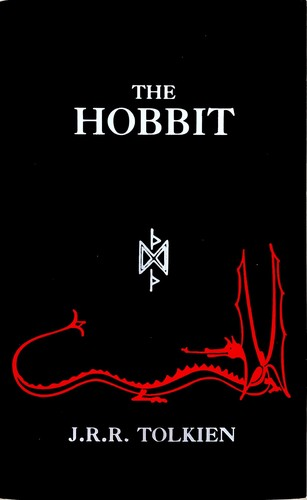


--- Current Library Catalog ---
        title          author        ISBN
0  The Hobbit  J.R.R. Tolkien  0261102214
1        1984   George Orwell  0451524934


In [15]:
import my_library as lib
import importlib

# Reload the my_library module to reflect recent changes
importlib.reload(lib)

# 1. Fetch a real book cover (The Hobbit - ISBN: 0261102214)
cover = lib.download_and_display_cover("0261102214")

# Display the image in your notebook
if cover:
    display(cover)

# 2. Create a catalog using your pandas-based function
my_data = [
    {"title": "The Hobbit", "author": "J.R.R. Tolkien", "ISBN": "0261102214"},
    {"title": "1984", "author": "George Orwell", "ISBN": "0451524934"}
]
shelf = lib.create_book_shelf(my_data)

print("\n--- Current Library Catalog ---")
print(shelf)

Folder 'book_covers' ready!
All book covers downloaded!


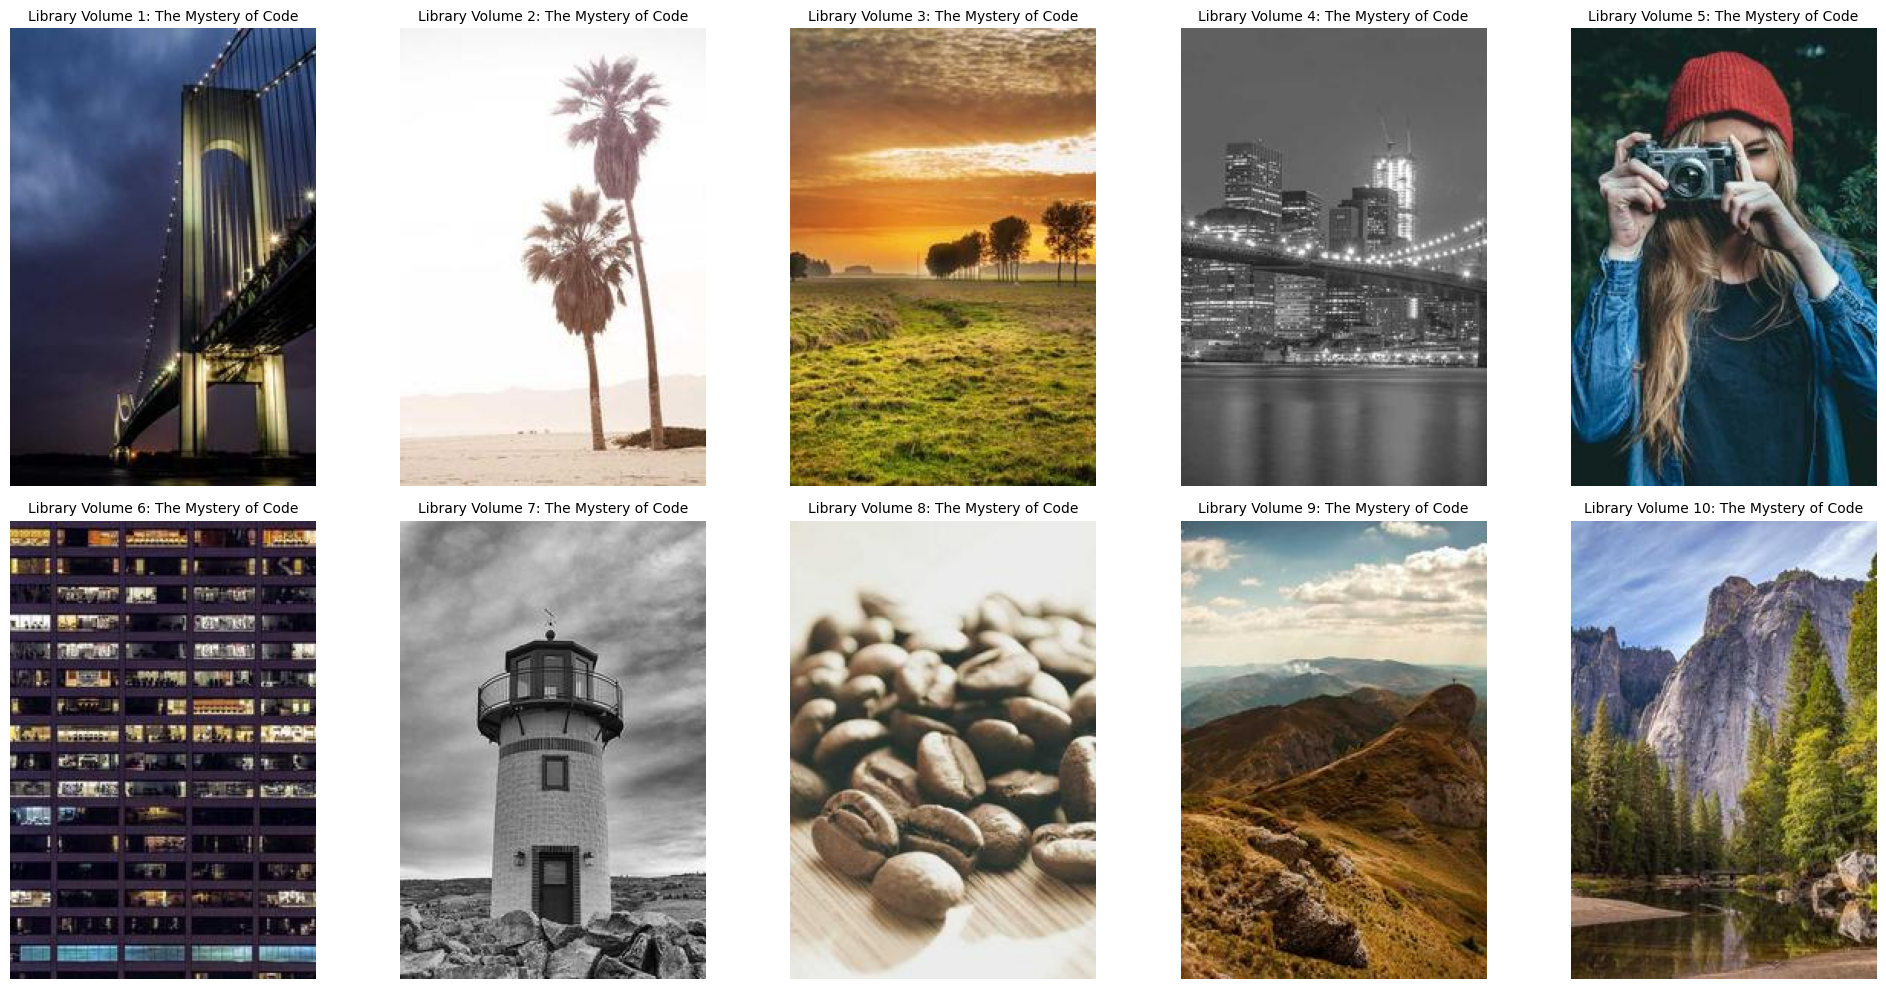

In [17]:
import os
import requests
import matplotlib.pyplot as plt
from PIL import Image

# --- STEP 1: Create the Library Folder ---
os.makedirs('book_covers', exist_ok=True)
print("Folder 'book_covers' ready!")

# --- STEP 2: Download the Covers (The Loop) ---
# I'll use some placeholder book IDs for the example
for i in range(10):
    # Using a placeholder image service for book covers
    img_url = f"https://picsum.photos/seed/{i+50}/200/300"

    img_data = requests.get(img_url).content
    with open(f'book_covers/book_{i}.jpg', 'wb') as handler:
        handler.write(img_data)

print("All book covers downloaded!")

# --- STEP 3: Create the Gallery (The Grid) ---
plt.figure(figsize=(20, 10))

for i in range(10):
    # 1. Open the book cover
    img = Image.open(f'book_covers/book_{i}.jpg')

    # 2. Assign a "Book Name" (Since we don't have real data results here)
    book_name = f"Library Volume {i+1}: The Mystery of Code"

    # 3. Create the subplot (2 rows, 5 columns)
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)

    # 4. Add the title (The book name)
    plt.title(book_name, fontsize=10, wrap=True)
    plt.axis('off')

plt.tight_layout()
plt.show()